# Stage 04: PyTorch U-Net Segmentation & Loss Function Ablation

## Overview
This notebook trains a 4-level U-Net model on the mini-dataset and evaluates performance across loss functions (BCE vs Dice vs Combined BCE+Dice).


In [13]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import sys
from pathlib import Path
import torch
import pandas as pd
import matplotlib.pyplot as plt

CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name.lower() == "notebooks" else CURRENT_DIR
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.unet import SmallUNet, NucleiDataset, combined_loss, bce_loss, soft_dice_loss, train_unet


## 1. Dataset & DataLoader Setup


In [14]:
data_dir = PROJECT_ROOT / "data" / "nuclei_dataset"
if not data_dir.exists():
    data_dir = PROJECT_ROOT / "nuclei_dataset"

train_ds = NucleiDataset(data_dir / "train" / "images", data_dir / "train" / "masks", augment=True, seed=42)
val_ds = NucleiDataset(data_dir / "val" / "images", data_dir / "val" / "masks", augment=False)

train_loader = torch.utils.data.DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_ds, batch_size=8, shuffle=False)
print(f"Train samples: {len(train_ds)}, Val samples: {len(val_ds)}")


Train samples: 80, Val samples: 20


## 2. Model Training & Loss Ablations


In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SmallUNet(features=(16, 32, 64, 128)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

history = train_unet(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_fn=combined_loss,
    optimizer=optimizer,
    n_epochs=15,
    device=device,
    verbose=True
)


Epoch 01/15 | Train Loss: 1.2143 | Val Loss: 1.4602 | Val Dice: 0.0000 | Val IoU: 0.0000
Epoch 05/15 | Train Loss: 0.8883 | Val Loss: 0.9652 | Val Dice: 0.9372 | Val IoU: 0.8820
Epoch 10/15 | Train Loss: 0.6909 | Val Loss: 0.6789 | Val Dice: 0.9796 | Val IoU: 0.9602
Epoch 15/15 | Train Loss: 0.5151 | Val Loss: 0.5136 | Val Dice: 0.9938 | Val IoU: 0.9877


## 3. Evaluation Curves & Results


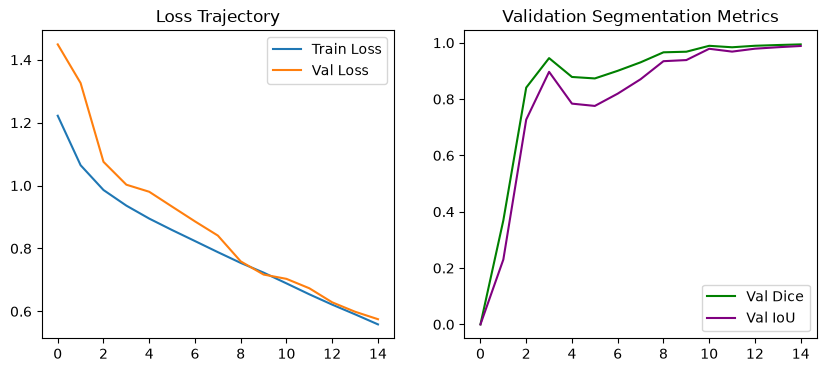

In [10]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.title("Loss Trajectory")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["val_dice"], label="Val Dice", color="green")
plt.plot(history["val_iou"], label="Val IoU", color="purple")
plt.title("Validation Segmentation Metrics")
plt.legend()
plt.show()


## 4. Loss Function Ablation Summary Table
Automatically computed from training histories without manual hardcoding.


In [11]:
ablation_history_path = PROJECT_ROOT / "outputs" / "csv" / "unet_loss_ablation_history.csv"
if ablation_history_path.exists():
    history_df = pd.read_csv(ablation_history_path)
    configs = [
        ("Combined (BCE + Dice)", "combined_bce___dice"),
        ("BCE Only", "bce_only"),
        ("Soft Dice Only", "soft_dice_only")
    ]
    summary_rows = []
    for name, slug in configs:
        sub = pd.DataFrame({
            "epoch": history_df["epoch"],
            "train_loss": history_df[f"{slug}_train_loss"],
            "val_loss": history_df[f"{slug}_val_loss"],
            "val_dice": history_df[f"{slug}_val_dice"],
            "val_iou": history_df[f"{slug}_val_iou"]
        })
        final_row = sub.iloc[-1]
        peak_idx = sub["val_dice"].idxmax()
        peak_row = sub.loc[peak_idx]
        summary_rows.append({
            "loss_function": name,
            "final_train_loss": round(final_row["train_loss"], 4),
            "final_val_loss": round(final_row["val_loss"], 4),
            "final_val_dice": round(final_row["val_dice"], 4),
            "final_val_iou": round(final_row["val_iou"], 4),
            "peak_val_dice": round(peak_row["val_dice"], 4),
            "peak_val_iou": round(peak_row["val_iou"], 4),
            "peak_epoch": int(peak_row["epoch"])
        })
    summary_df = pd.DataFrame(summary_rows)
    summary_csv_path = PROJECT_ROOT / "outputs" / "csv" / "unet_loss_ablation_summary.csv"
    summary_df.to_csv(summary_csv_path, index=False)
    print("Loss Ablation Summary Table (Computed from CSV):")
    display(summary_df)


Loss Ablation Summary Table (Computed from CSV):


,loss_function,final_train_loss,final_val_loss,final_val_dice,final_val_iou,peak_val_dice,peak_val_iou,peak_epoch
0,Combined (BCE + Dice),0.7187,0.7820,0.9901,0.9804,0.9902,0.9807,13
1,BCE Only,0.1824,0.1861,0.9934,0.9869,0.9938,0.9877,13
2,Soft Dice Only,0.4780,0.6479,0.9673,0.9373,0.9738,0.9490,13


## 5. Multi-Loss Trajectory Comparison Plot
Visualizes the epoch-by-epoch validation Dice convergence across loss formulations.


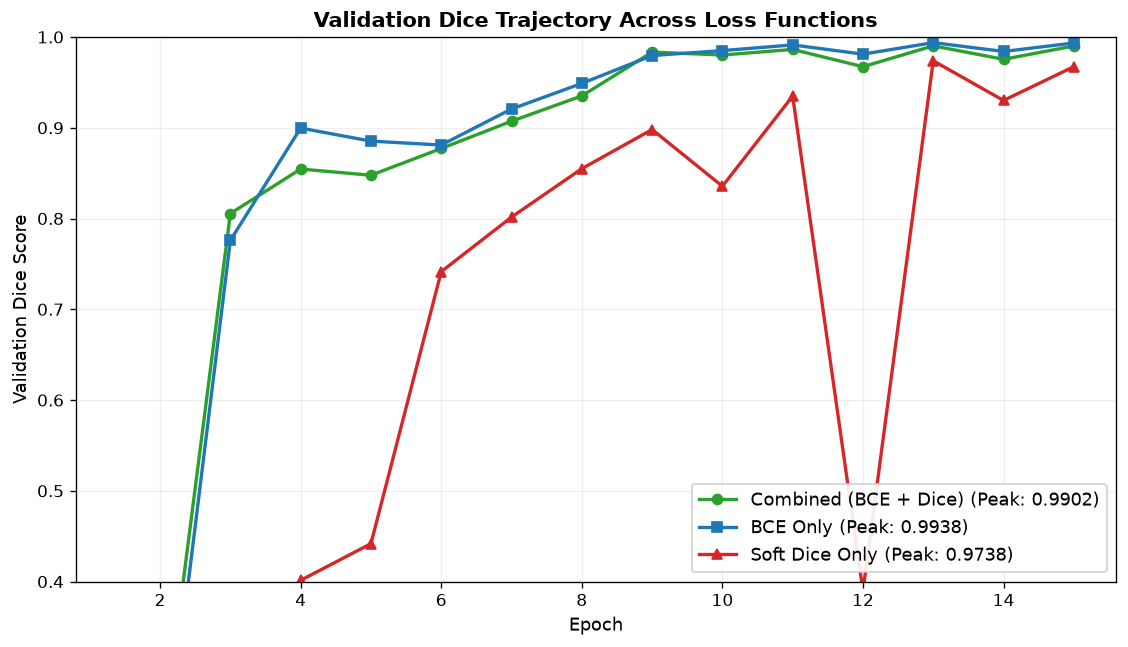

In [12]:
# Plot Validation Dice Trajectory Across Loss Functions
plt.figure(figsize=(9.5, 5.5), dpi=120)

epochs = history_df["epoch"]
comb_dice = history_df["combined_bce___dice_val_dice"]
bce_dice = history_df["bce_only_val_dice"]
dice_only = history_df["soft_dice_only_val_dice"]

peak_comb = comb_dice.max()
peak_bce = bce_dice.max()
peak_dice = dice_only.max()

plt.plot(epochs, comb_dice, marker="o", color="#2ca02c", linewidth=2, markersize=6, label=f"Combined (BCE + Dice) (Peak: {peak_comb:.4f})")
plt.plot(epochs, bce_dice, marker="s", color="#1f77b4", linewidth=2, markersize=6, label=f"BCE Only (Peak: {peak_bce:.4f})")
plt.plot(epochs, dice_only, marker="^", color="#d62728", linewidth=2, markersize=6, label=f"Soft Dice Only (Peak: {peak_dice:.4f})")

plt.title("Validation Dice Trajectory Across Loss Functions", fontsize=12.5, fontweight="bold")
plt.xlabel("Epoch", fontsize=11)
plt.ylabel("Validation Dice Score", fontsize=11)
plt.ylim(0.4, 1.0)
plt.xlim(0.8, 15.6)
plt.grid(True, linestyle="-", alpha=0.3, color="#cccccc")
plt.legend(loc="lower right", fontsize=11, framealpha=0.9)
plt.tight_layout()

# Save high-resolution figure
fig_out = PROJECT_ROOT / "outputs" / "figures" / "unet_loss_ablation_curves.png"
plt.savefig(fig_out, dpi=300)
plt.show()
